In [2]:
# load packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

In [ ]:
FIGURE_DIR = "../output/figures/workplace_dependence"
os.makedirs(FIGURE_DIR, exist_ok=True)

def save_figure(filename_stem, directory=FIGURE_DIR):
    """Save the current matplotlib figure as pdf, png and svg."""
    for ext in ["pdf", "png", "svg"]:
        plt.savefig(f"{directory}/{filename_stem}.{ext}", dpi=300, bbox_inches="tight")

cluster_label_map = {
    0: 'Mixed Shift cluster',
    1: 'Day Shift cluster',
    2: 'Weekend Shift cluster',
}
colors = [ '#7570b3',  '#d95f02','#1b9e77']
color_map = {0: colors[0], 1: colors[1], 2: colors[2]}

In [4]:
# read 48hrs of telekom data 
file_path = "../output/data/48hr_averages/curfew_avg48hrs.pkl"
open_path = "../output/data/48hr_averages/open_avg48hrs_clustered.pkl"

curfew = pd.read_pickle(file_path)
opening = pd.read_pickle(open_path)

In [5]:
df = pd.merge(opening, curfew, on=['raster_id', 'hour_reordered'], suffixes=('_open', '_curfew'))

In [6]:
# Drop rows missing any of the columns 
df = df.dropna(subset=['loc_work_no0_open', 'loc_work_no0_curfew', 'work_cluster'])

In [7]:
df['delta_work'] = df['loc_work_no0_curfew'] -  df['loc_work_no0_open']
df['delta_work_percent'] = (df['loc_work_no0_curfew'] -  df['loc_work_no0_open'])/ df['loc_work_no0_open']

In [8]:
# hour 12 - established peak workday hour 
diff = df[df['hour_reordered'] == 12]

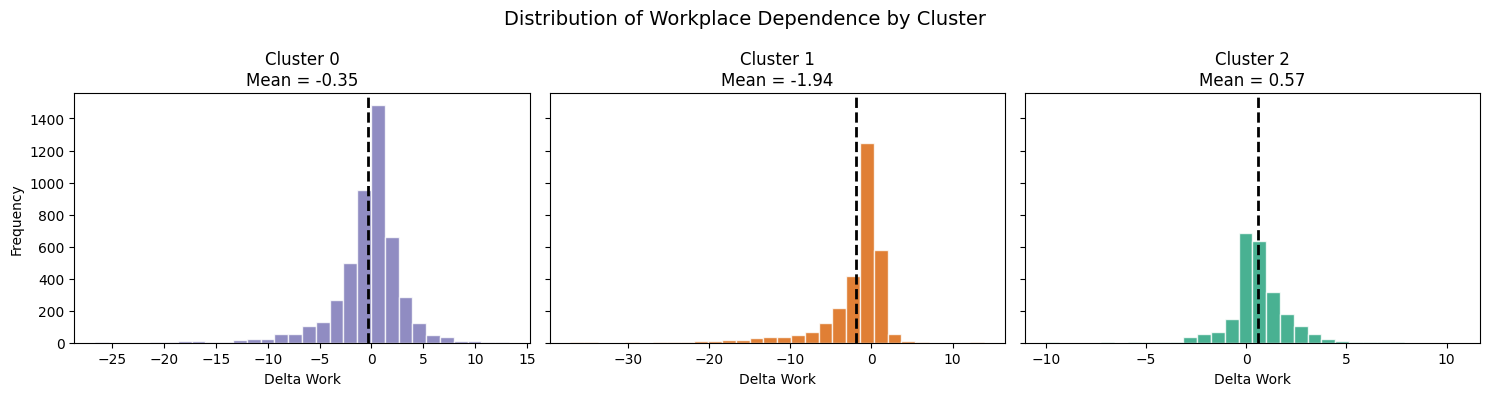

In [18]:
clusters = sorted(diff['work_cluster'].dropna().unique())

fig, axes = plt.subplots(1, len(clusters), figsize=(15, 4), sharey=True)

if len(clusters) == 1:
    axes = [axes]

for ax, clust in zip(axes, clusters):
    subset = diff.loc[diff['work_cluster'] == clust, 'delta_work'].dropna()

    # Histogram
    ax.hist(subset, bins=30, color=color_map[int(clust)], alpha=0.8, edgecolor='white')

    # Mean line
    mean_val = subset.mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=2)

    # Titles
    ax.set_title(f'Cluster {int(clust)}\nMean = {mean_val:.2f}')
    ax.set_xlabel('Delta Work')

axes[0].set_ylabel('Frequency')

plt.suptitle('Distribution of Workplace Dependence by Cluster', fontsize=14)
plt.tight_layout()
save_figure("delta_work_hist_by_cluster")
plt.show()

In [10]:
diff['delta_work'].mean()

-0.596529241682252

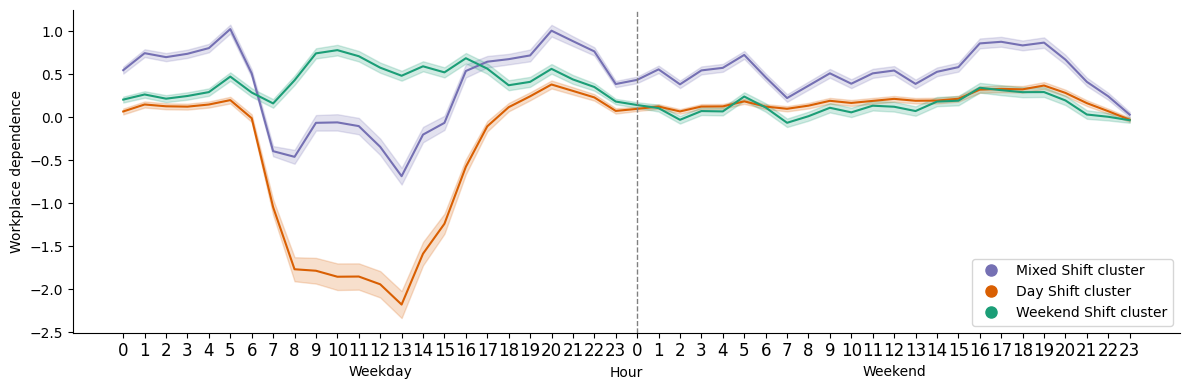

In [19]:
# Compute mean and standard error for each cluster
grouped = df.groupby(['hour_reordered', 'work_cluster'])['delta_work']
mean_delta = grouped.mean().unstack()
se_delta = grouped.sem().unstack()  # Standard error

# Custom labels for legend, built from the shared placeholder map above -
# work_cluster may be float (NaN for non-workplace raster_ids upstream), so match on int(c)
cluster_labels = {c: cluster_label_map.get(int(c), f'Cluster {int(c)}') for c in mean_delta.columns}

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))

# Plot delta_work with confidence intervals
for i, cluster in enumerate(mean_delta.columns):

    ax.plot(mean_delta.index,
            mean_delta[cluster],
            linestyle='-',
            color=colors[i])

    # 95% CI shading
    ax.fill_between(mean_delta.index,
                    mean_delta[cluster] - 1.96 * se_delta[cluster],
                    mean_delta[cluster] + 1.96 * se_delta[cluster],
                    color=colors[i],
                    alpha=0.2)

# Adjust xticks to go from 0-23 and then repeat
xticks = list(range(24)) + list(range(24))
plt.xticks(list(range(48)), xticks, fontsize=12)

# Add "Weekday" and "Weekend" labels
y_offset = plt.ylim()[0] - (plt.ylim()[1] - plt.ylim()[0]) * 0.1
plt.text(12, y_offset, 'Weekday', ha='center', va='top', fontsize=10)
plt.text(36, y_offset, 'Weekend', ha='center', va='top', fontsize=10)

# Formatting
ax.set_xlabel('Hour', fontsize=10)
ax.set_ylabel('Workplace dependence', fontsize=10)
ax.axvline(x=24, color='gray', linestyle='--', linewidth=1)

# Cluster legend dots (same style as before)
dot_handles = [
    mlines.Line2D([], [],
                  color=colors[int(i)],
                  marker='o',
                  linestyle='None',
                  markersize=8,
                  label=cluster_labels[i])
    for i in cluster_labels
]

ax.legend(handles=dot_handles,
          ncol=1,
          loc='lower right',
          fontsize=10,
          frameon=True)

sns.despine()
plt.tight_layout()
save_figure("change_work_activity_byclust")
plt.show()